# 🎲 Sample, Then Diagonalize

### *A Qiskit Fall Fest lab challenge celebrating 10 years of IBM Quantum in the cloud* 🎉

In May 2016, IBM put the first real quantum computer on the cloud: a 5-qubit processor
that anyone, anywhere could program from a browser. A decade later, this hands-on
Jupyter notebook series takes you from those first cloud circuits to a modern
frontier: **sample-based quantum diagonalization (SQD)**, the algorithm behind some of
the largest quantum chemistry experiments ever run on real quantum hardware.

**SQD from scratch, core notebook 1 of 3** · ⏱ about 50 minutes

What if a quantum computer didn't have to *solve* your problem, but only had to
*point you toward* the answer? That question is the heart of SQD, and in this first
notebook we build the entire idea with nothing but a small magnet model, so every
piece can be examined directly.

Three terms will do the heavy lifting in this series, so here they are in plain words.
Every physical system comes with a **Hamiltonian**: its energy rulebook, the thing
that assigns an energy score to every state the system could possibly occupy. The
system's **ground state** is the lowest-energy state allowed by that rulebook. It may
be one arrangement, or it may be a blend of many arrangements. And **diagonalizing**
is how a computer reads the rulebook: a standard routine that extracts the menu of
energies the rules actually allow, lowest first. Ground states are what much of
chemistry and materials science boils down to: they decide whether a drug molecule
binds, how a battery electrode holds charge, which way a magnet points. Section 1
makes all three ideas precise; for now, "energy rulebook", "lowest-energy state",
and "read off the menu" are all you need.

**🎯 By the end you will be able to:**
- explain why finding ground states is exponentially hard,
- show that many ground states are *concentrated* on just a few bitstrings,
- crop a big Hamiltonian down to a few sampled bitstrings and diagonalize the small block,
- demonstrate the central result: **a mediocre quantum circuit still gives an excellent energy.**

**You should already know:** qubits, circuits, gates, and measurement in Qiskit.
No chemistry needed yet (that's notebook 2).

> **🧭 Feeling stretched by this notebook?** That's common, and there's a well-designed
> on-ramp: the free
> [Use a quantum computer today](https://quantum.cloud.ibm.com/learning/en/courses/use-a-qc-today)
> course on IBM Quantum Learning has you running programs on a real quantum computer
> with no background required. Work through it first, then come back; this lab will
> still be here.

**How to use this notebook:** run cells top to bottom. Along the way you'll meet
**🧠 Checkpoints** (think first, then click to reveal the answer) and
**✍️ Your turn** cells (write your code between the `YOUR CODE HERE` markers; a
hidden solution follows right below each one). Optional background is folded into
click-to-open notes so the main path stays concrete.

In [1]:
# If you are on Google Colab or a fresh environment, uncomment and run:
# %pip install "numpy>=2.3.2" "qiskit==2.5.1" "matplotlib==3.11.1" "pylatexenc==2.10"

import numpy as np
import matplotlib.pyplot as plt
import qiskit
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from qiskit.quantum_info import SparsePauliOp, Statevector

print("qiskit", qiskit.__version__)

qiskit 2.5.1


## 1 · The wall: $2^n$

The **ground state** of a physical system is its lowest-energy state. Ground-state
questions matter throughout chemistry, physics, and materials science: they ask which
state the system prefers to settle into.
A ground state can be one basis arrangement, but in a quantum problem it is usually a
superposition of several arrangements.

In matrix language the recipe is simple: write the Hamiltonian $H$ as a square table,
run the routine called `np.linalg.eigh(H)`, and read the lowest returned eigenvalue.
The catch is the
size of the table: for $n$ qubits, $H$ is a $2^n \times 2^n$ matrix.

Our model is a chain of tiny magnets, one per qubit. Neighboring magnets prefer to
align, while a sideways field of strength $g$ mixes arrangements that differ by one
flipped magnet:

$$H \;=\; -\sum_{i} Z_i Z_{i+1} \;-\; g \sum_i X_i$$

We will begin with three magnets, where the whole 8-by-8 rulebook fits on one screen.
Look at the concrete table first. The optional note below unpacks every symbol and the
linear algebra when you are ready.

<details>
<summary>🔎 <b>Under the hood: matrices, eigenvalues, and every symbol in the Ising rule</b></summary>

The **ground state** of a physical system is its lowest-energy state. Ground-state
questions matter throughout chemistry, physics, and materials science: they ask which
state the system prefers to settle into.

In matrix language the task sounds remarkably simple, but it leans on two
words worth unpacking (one of them is in this notebook's title): write the Hamiltonian
$H$ as a matrix, then **diagonalize** it to find its lowest **eigenvalue**. In plain
words, skipping the linear-algebra course:

- $H$ is a **matrix**, which at our level means nothing more than a square table of
  numbers. Hiding inside that table is a complete menu of the energies the system is
  allowed to settle at. **Diagonalizing** is the procedure that extracts the menu from
  the table. In code it's a single call, `np.linalg.eigh(H)`, and you're welcome to
  treat it as a black box.
- **Why the name?** A matrix with zeros everywhere except its diagonal is called
  *diagonal*, and for one of those the menu is simply sitting on the diagonal, no work
  needed. Real rulebooks are rarely so kind: ours will scribble nonzero numbers *off*
  the diagonal, and in a moment you'll see exactly which of its rules does the
  scribbling, and exactly where. Diagonalizing is the change of viewpoint that makes
  all those off-diagonal numbers vanish, and once they're gone, what's left on the
  diagonal *is* the menu.
- The menu entries are called **eigenvalues**. The lowest one is the ground-state
  energy we're after; that's the whole reason we diagonalize.
- Each eigenvalue comes with an **eigenvector**: the recipe for the state that has
  that energy (section 2 unpacks exactly what's written in the recipe). The
  eigenvector attached to the lowest eigenvalue *is* the ground state.

So the plan is: build the table, ask `eigh` for the menu, read off the lowest energy
on the menu. (One handy detail: `eigh` hands the menu back **already sorted, lowest
first**, so the ground-state energy is simply entry `[0]`, and its eigenvector is
column `[:, 0]`.)
The catch is the size of the table: for $n$ qubits, $H$ is a $2^n \times 2^n$ matrix.

Our model system for this notebook: a chain of tiny magnets ("spins"), one per qubit.
Each magnet wants to point the same way as its neighbors, while a sideways magnetic
field tries to twist every one of them. Physicists call this a *transverse-field Ising
chain*. The same formula works for any chain length, so we'll learn to read it on a
chain of just **three** magnets, small enough that nothing can hide:

$$H \;=\; -\sum_{i} Z_i Z_{i+1} \;-\; g \sum_i X_i$$

That line can look intimidating, so let's take it apart piece by piece. There are only
four ideas in it:

- **$H$ is an energy rulebook.** A Hamiltonian assigns an energy to every possible
  arrangement of the system, and lower energy means "more comfortable". This particular
  rulebook contains two *kinds* of rules, one per term of the formula: a **neighbor
  rule**, applied once to every adjacent pair of spins, and a **nudge rule**, applied
  once to every individual spin. The minus signs mean each rule *lowers* the energy of
  whatever it favors.
- **$\sum_i$ just means "add up".** The big sigma is a loop, nothing more: "repeat the
  thing that follows for each position $i$, and add the results." If you can read a
  `for` loop, you can read a $\sum$. The first one loops over the neighboring pairs
  of magnets (2 pairs in our 3-magnet chain), the second over every individual magnet
  (all 3). So the "two rules" get applied 5 times in total.
- **$Z_i Z_{i+1}$ is a "do neighbors agree?" check.** You know $Z$ as a gate; here it
  plays a second role, as a *question* asked about qubits $i$ and $i+1$: it works out to
  $+1$ when the two neighbors match (`00` or `11`) and $-1$ when they clash (`01` or
  `10`). Combined with the minus sign out front, **matching neighbors lower the
  energy**. That's the whole "it's a magnet" part: spins are comfortable when aligned.
  Note this rule only *scores* an arrangement; it never changes one.
- **$g \, X_i$ is the sideways nudge.** You know $X$ too: it's the flip gate. Each
  $X_i$ flips exactly one spin, qubit $i$, and the sum applies one such nudge to
  **every magnet in the chain**: all three feel the sideways field, each through
  its own term. Unlike the neighbor rule, this one doesn't score arrangements at all:
  it **connects** each arrangement to the arrangements one flip away. The physical
  effect is not spins flipping all the way over; it's the system's most comfortable
  state becoming a **blend** (a superposition, in the language you know): mostly the
  aligned arrangements, with a small amount of their one- and two-flip neighbors
  mixed in. The number $g$ sets the strength of that blending, and this term is
  what makes the problem genuinely quantum: it stops the answer from
  being any single bitstring.

Let's sanity-check the neighbor rule by hand on three arrangements of our 3 magnets:

| bitstring | neighbor pairs that match | pairs that clash | neighbor-rule energy |
|---|---|---|---|
| `000` | 2 | 0 | $-2$ |
| `001` | 1 | 1 | $-1 + 1 = 0$ |
| `010` | 0 | 2 | $+2$ |

So `000` (and by symmetry `111`) is the most comfortable arrangement, and the isolated
flipped magnet in the middle (`010`) is the least, exactly what you'd expect from a real
magnet. The sideways nudge then blends arrangements together; the competition between
the two rules is what makes the problem interesting (and genuinely quantum). Keep the
nudge's job in mind: in a moment you'll see the **entire rulebook as an actual
8-by-8 table**, watch the nudge write its numbers into it as you slide $g$, and later
meet its ripples around section 2's two tall towers.

You don't need to manipulate these symbols yourself: the code below builds $H$ for
any chain length. All you need is the physical reading: **align with your neighbors,
resist a sideways nudge of strength $g$.** And you're about to sweep $g$ yourself.

</details>

In [2]:
def build_hamiltonian(n, g):
    """Transverse-field Ising chain as a SparsePauliOp."""
    terms = [("ZZ", [i, i + 1], -1.0) for i in range(n - 1)]
    terms += [("X", [i], -g) for i in range(n)]
    return SparsePauliOp.from_sparse_list(terms, num_qubits=n)

**The whole rulebook, on one screen.** Three magnets have only $2^3 = 8$ possible
arrangements, so the entire Hamiltonian fits in an 8-by-8 table we can simply look
at. Below, every row and every column is labeled by one arrangement of the three
magnets (the arrows show each magnet's orientation), and the **player's slider bar
is your $g$-knob**: drag it to set the field strength, or press ▶ to sweep it.

- **Blue diagonal:** the neighbor rule's energy for each arrangement, exactly the
  numbers from our worked table. They never move, whatever $g$ does.
- **Purple cells:** the nudge's entries, sitting precisely where the row and column
  arrangements differ by **one flipped magnet**; every one of them equals $-g$. These
  are the off-diagonal entries that make diagonalization necessary. Slide $g$ to zero
  and they all read 0.0 (we keep a faint tint so you can see where the nudge's slots
  live): the table is diagonal, the menu sits in plain sight, and `eigh` would have
  nothing to do. Slide $g$ up and watch the nudge write itself into the rulebook,
  linking each arrangement to its 3 one-flip neighbors, and handing `eigh` real work.
- **White cells:** row and column differ by two or more flips. Their entries are exactly
  zero because this Hamiltonian has no rule that flips two or more magnets at once. We
  leave those zeros blank so the diagonal and one-flip pattern are easier to see.

In [3]:
import matplotlib.animation as animation
from IPython.display import HTML

labels3 = [f"{i:03b}" for i in range(8)]
g_slider = np.round(np.arange(0.0, 2.01, 0.2), 1)
H3_tables = [build_hamiltonian(3, g_val).to_matrix().real for g_val in g_slider]

BLUE_BG = np.array([0.84, 0.91, 1.00])
PURPLE = np.array([0.54, 0.25, 0.99])


def draw_mini_chain(ax, bits, x, y, dx=0.24, size=0.3):
    """Three magnets as arrows: blue up = 0, red down = 1 (y-axis is inverted here)."""
    for k, b in enumerate(bits):
        xx = x + (k - 1) * dx
        tip, tail = (y - size, y + size) if b == "0" else (y + size, y - size)
        ax.annotate("", (xx, tip), (xx, tail),
                    arrowprops=dict(arrowstyle="-|>", lw=2.0,
                                    color="#4589ff" if b == "0" else "#fa4d56"))


fig, ax = plt.subplots(figsize=(7.8, 7.8), layout="constrained")


def show_rulebook(frame):
    ax.clear()
    g_val, H3 = g_slider[frame], H3_tables[frame]
    cells = np.ones((8, 8, 3))
    for i in range(8):
        for j in range(8):
            if i == j:
                cells[i, j] = BLUE_BG
            elif bin(i ^ j).count("1") == 1:
                t = 0.10 + 0.55 * g_val / 2.0
                cells[i, j] = (1 - t) + t * PURPLE
    ax.imshow(cells, extent=(-0.5, 7.5, 7.5, -0.5), zorder=0)
    for i in range(8):
        for j in range(8):
            if i == j or bin(i ^ j).count("1") == 1:
                ax.text(j, i, f"{H3[i, j]:.1f}".replace("-0.0", "0.0"),
                        ha="center", va="center", fontsize=9)
    for i in range(8):
        draw_mini_chain(ax, labels3[i], -1.6, i)    # row labels: the magnets
        draw_mini_chain(ax, labels3[i], i, -1.6)    # column labels: the magnets
    ax.set_xlim(-2.6, 7.6), ax.set_ylim(7.6, -2.6)
    ax.set_xticks([]), ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(f"the whole rulebook for 3 magnets · g = {g_val:.1f}", fontsize=13)
    ax.set_xlabel("blue diagonal = neighbor-rule energies (fixed) · "
                  "purple = nudge entries, all equal to -g", fontsize=9)


anim = animation.FuncAnimation(fig, show_rulebook, frames=len(g_slider), interval=700)
plt.close(fig)  # show only the player below
HTML(anim.to_jshtml(default_mode="once"))

**Static fallback.** The player above is useful for sweeping $g$, but the two fixed
snapshots below carry the same essential comparison and remain readable in notebook
viewers that do not execute embedded JavaScript.

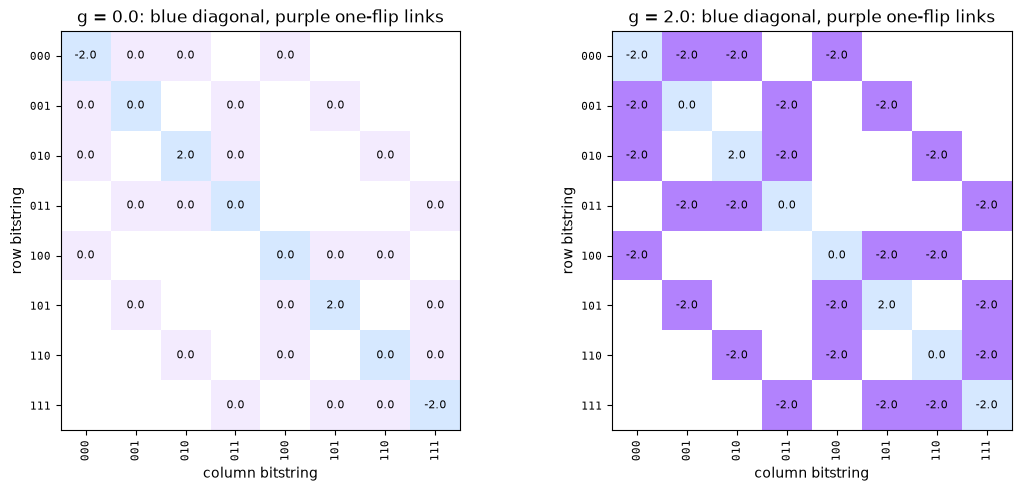

In [4]:
def plot_rulebook_snapshot(ax, g_val):
    H3 = build_hamiltonian(3, g_val).to_matrix().real
    cells = np.ones((8, 8, 3))
    for i in range(8):
        for j in range(8):
            if i == j:
                cells[i, j] = BLUE_BG
            elif bin(i ^ j).count("1") == 1:
                t = 0.10 + 0.55 * g_val / 2.0
                cells[i, j] = (1 - t) + t * PURPLE
    ax.imshow(cells, extent=(-0.5, 7.5, 7.5, -0.5))
    for i in range(8):
        for j in range(8):
            if i == j or bin(i ^ j).count("1") == 1:
                ax.text(j, i, f"{H3[i, j]:.1f}".replace("-0.0", "0.0"),
                        ha="center", va="center", fontsize=8)
    ax.set_xticks(range(8)), ax.set_yticks(range(8))
    ax.set_xticklabels(labels3, rotation=90, family="monospace", fontsize=8)
    ax.set_yticklabels(labels3, family="monospace", fontsize=8)
    ax.set_xlabel("column bitstring")
    ax.set_ylabel("row bitstring")
    ax.set_title(f"g = {g_val:.1f}: blue diagonal, purple one-flip links")


fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), layout="constrained")
for ax, g_val in zip(axes, [0.0, 2.0]):
    plot_rulebook_snapshot(ax, g_val)
plt.show()

**🧠 Checkpoint 1.** The lowest blue number in the table is $-2.0$ at every setting
of the slider. Is the *true* ground-state energy also $-2.0$? Form a guess, then run
the cell below and check yourself.

<details>
<summary>💡 <b>Check your answer</b></summary>

Only at $g = 0$, where the table is diagonal and the menu is sitting in plain sight.
When $g > 0$, the purple entries couple different bitstrings. A superposition can then
use those $-gX_i$ links to lower its energy in a way no single diagonal entry can. At
$g = 2.0$, `eigh` returns about $-6.2498$: that is about $4.25$ below the best diagonal
entry, $-2.0$. So $-4.25$ is not the ground-state energy; it is the amount of lowering
that the diagonal-only shortcut misses.

The diagonal's "naive answer" means pretending the off-diagonal entries are zero and
simply taking the smallest diagonal number. That shortcut is exact for a diagonal
matrix, but not after the purple couplings mix bitstrings.

Note this for later: the lowest diagonal entry is exactly the best you can do with a
*single arrangement*. Later in this notebook you'll close that same gap a different
way: not by rotating the table, but by adding more arrangements to a shortlist.

</details>

In [5]:
# is the lowest diagonal entry the true ground energy? check a few slider settings:
for g_val in [0.0, 0.2, 1.0, 2.0]:
    menu = np.linalg.eigvalsh(build_hamiltonian(3, g_val).to_matrix().real)
    print(f"g = {g_val:3.1f}:  lowest diagonal entry = -2.0   true ground energy = {menu[0]:7.4f}")

g = 0.0:  lowest diagonal entry = -2.0   true ground energy = -2.0000
g = 0.2:  lowest diagonal entry = -2.0   true ground energy = -2.0578
g = 1.0:  lowest diagonal entry = -2.0   true ground energy = -3.4940
g = 2.0:  lowest diagonal entry = -2.0   true ground energy = -6.2498


And that's the *entire* problem, laid bare. For three magnets you'd never need a
quantum computer: `np.linalg.eigh` diagonalizes an 8-by-8 table in microseconds. The wall
appears because every magnet you add **doubles** the table. So for the rest of this
notebook our model system is a chain of **eight** magnets: same rules, same formula,
but the table is now $256 \times 256$: still easy for a laptop, yet big enough for
every idea that follows to be meaningful.

In [6]:
n = 8  # number of spins (qubits) from here on

g = 0.4
H = build_hamiltonian(n, g)
H_mat = H.to_matrix().real  # 2^8 = 256 rows: still easy for a laptop

eigenvalues, eigenvectors = np.linalg.eigh(H_mat)  # the menu, sorted lowest first
E_exact = eigenvalues[0]   # so entry 0 is the ground-state energy
psi0 = eigenvectors[:, 0]  # and column 0 is its recipe: the ground state, our "answer key"

print(f"matrix size: {H_mat.shape[0]} x {H_mat.shape[1]}")
print(f"exact ground-state energy: {E_exact:.6f}")

matrix size: 256 x 256
exact ground-state energy: -7.405591


256 x 256 is nothing. But this approach has a hard limit.

**🧠 Checkpoint 2.** Storing *one* quantum state of $n = 50$ qubits means storing $2^{50}$
complex numbers (16 bytes each). Roughly how much memory is that?

<details>
<summary>💡 <b>Check your answer</b></summary>

$2^{50} \approx 1.1 \times 10^{15}$ amplitudes, times 16 bytes each: about **18 petabytes**,
just to *write down* one candidate state. Diagonalizing the matrix is far worse still.
Brute force is simply not an option, and 50 qubits is a *small* molecule.

</details>

## 2 · A fortunate fact: ground states are (often) concentrated

Here is the observation that saves us. It starts from something you already use every
time you run a circuit: a single qubit can sit in a *blend* of $|0\rangle$ and
$|1\rangle$, like the familiar $\left(|0\rangle + |1\rangle\right)/\sqrt{2}$ that an
`H` gate produces. The same idea scales up: **any** state of our 8 qubits is a blend of
all 256 possible bitstrings. As a formula:

$$|\psi_0\rangle = \sum_b c_b\,|b\rangle$$

Let's read it piece by piece, the same way we read $H$:

- $\sum_b$ is our loop again: "go through every bitstring $b$, all $2^n$ of them, and
  add up what follows."
- $|b\rangle$ is just an arrangement itself: $|00000000\rangle$, $|00000001\rangle$,
  and so on. These are called the **measurement basis** states because they're the
  outcomes a measurement can actually report; every shot of a circuit hands you exactly
  one such bitstring.
- $c_b$ is the **amplitude**: how much of bitstring $b$ is in the blend. This is the
  only number in the formula that carries real information. Its practical meaning is
  the one you already know from histograms: a measurement returns bitstring $b$ with
  probability $|c_b|^2$. Big amplitude = shows up often in your counts; amplitude
  zero = never shows up at all.

So "write the ground state in the measurement basis" just means: **list, for every
bitstring, how much of it the ground state contains.** A state you've met before makes
a perfect example: the Bell state $\left(|00\rangle + |11\rangle\right)/\sqrt{2}$ has
$c_{00} = c_{11} = 1/\sqrt{2} \approx 0.71$ and $c_{01} = c_{10} = 0$. Just two
bitstrings carry the entire state; the other two are simply absent.

In the worst case, all $2^n$ amplitudes matter equally and no shortlist exists. But for
many physical systems, **almost all of the weight sits on a handful of bitstrings**,
with the rest close to (though not exactly) zero. Our magnet's ground state turns out
to be "a Bell state with ripples". Let's look at it through that lens.

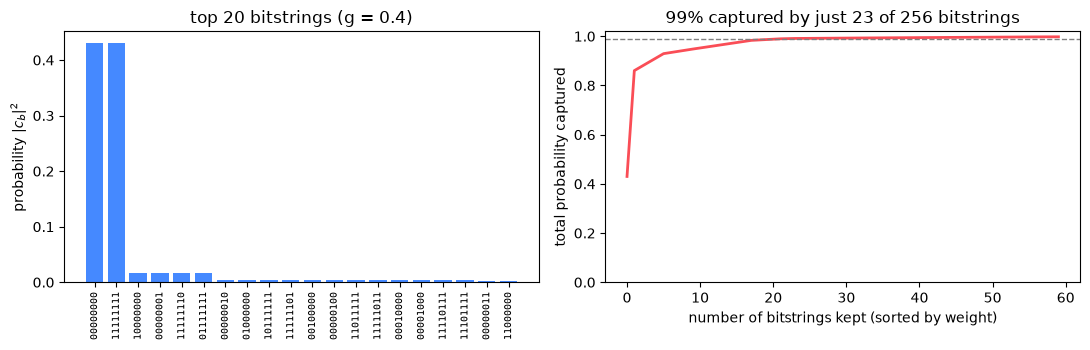

In [7]:
def plot_concentration(probs, title="", top=20, ax_pair=None):
    """Bar chart of the largest probabilities + cumulative curve."""
    order = np.argsort(probs)[::-1]
    sorted_p = probs[order]
    cumulative = np.cumsum(sorted_p)
    n_bits = int(np.log2(len(probs)))
    n99 = int(np.searchsorted(cumulative, 0.99) + 1)

    own_figure = ax_pair is None
    if own_figure:
        _, ax_pair = plt.subplots(1, 2, figsize=(11, 3.6))
    ax1, ax2 = ax_pair
    labels = [f"{idx:0{n_bits}b}" for idx in order[:top]]
    ax1.bar(range(top), sorted_p[:top], color="#4589ff")
    ax1.set_xticks(range(top))
    ax1.set_xticklabels(labels, rotation=90, fontsize=7, family="monospace")
    ax1.set_ylabel("probability $|c_b|^2$")
    ax1.set_title(f"top {top} bitstrings {title}")
    ax2.plot(cumulative[:60], lw=2, color="#fa4d56")
    ax2.axhline(0.99, ls="--", color="gray", lw=1)
    ax2.set_xlabel("number of bitstrings kept (sorted by weight)")
    ax2.set_ylabel("total probability captured")
    ax2.set_title(f"99% captured by just {n99} of {len(probs)} bitstrings")
    ax2.set_ylim(0, 1.02)
    if own_figure:
        plt.tight_layout()


probs = np.abs(psi0) ** 2
plot_concentration(probs, title=f"(g = {g})")
plt.show()

Two towers and some ripples. The towers are `00000000` and `11111111` (all spins aligned,
either way: it *is* a magnet). The ripples are states with one or two flipped spins.
Everything else, 200+ bitstrings, is essentially invisible.

How does the sideways field $g$ change the picture? Instead of adding a second
animation, compare two fixed regimes side by side. Each row below repeats the same two
views: the heaviest bitstrings on the left and cumulative captured probability on the
right.

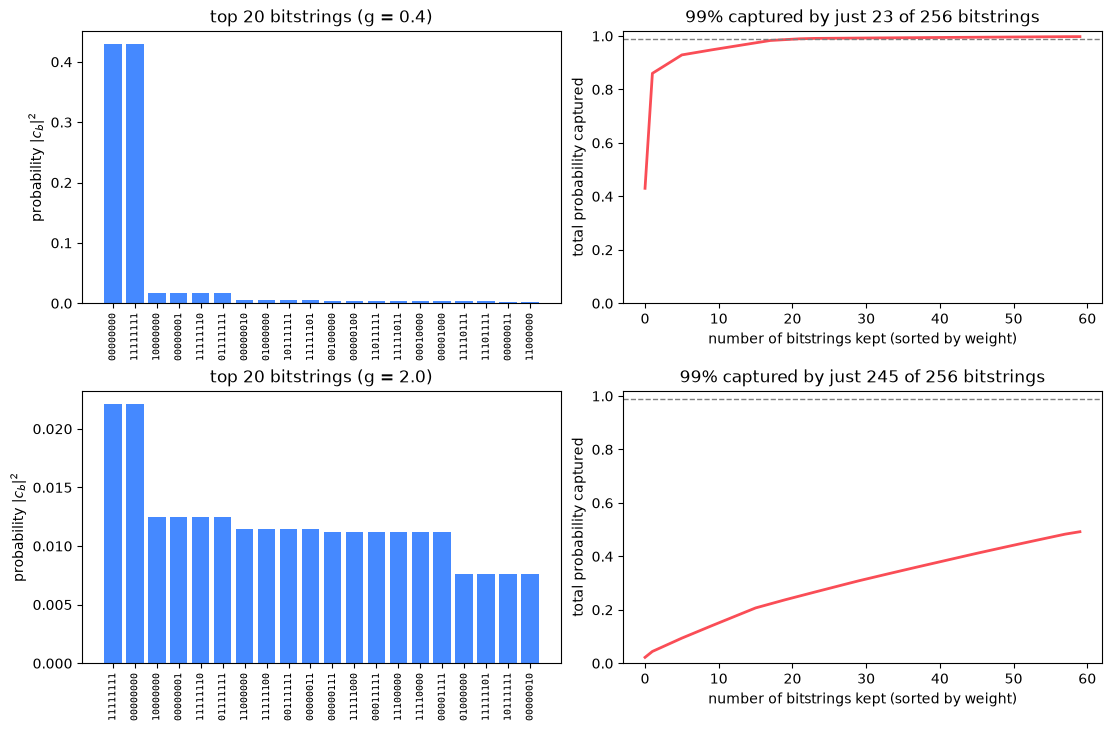

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7.2), layout="constrained")
for row, g_val in enumerate([0.4, 2.0]):
    Hg = build_hamiltonian(n, g_val).to_matrix().real
    _, vecs = np.linalg.eigh(Hg)
    plot_concentration(
        np.abs(vecs[:, 0]) ** 2,
        title=f"(g = {g_val:.1f})",
        ax_pair=axes[row],
    )
plt.show()

**🧠 Checkpoint 3.** At $g = 2.0$ the weight spreads over many more bitstrings than at
$g = 0.4$. If you wanted to describe the ground state with a short list of bitstrings,
which regime is friendlier, and what does that tell you about when our trick will work?

<details>
<summary>💡 <b>Check your answer</b></summary>

The small-$g$ regime is friendlier: a short list captures almost everything. The whole
strategy of "keep only the important bitstrings" works when the state is **concentrated
in the basis you measure in**. When the weight spreads out, you need a longer list to
reach the same quality. Good news for us: molecular ground states (notebooks 2 and 3)
are typically strongly concentrated, with one dominant configuration and a modest crowd
of important corrections.

</details>

## 3 · The move: diagonalize only where it matters

If only, say, 20 bitstrings matter, we don't need the $256 \times 256$ matrix. We can
**crop** it: keep only the rows and columns of those 20 bitstrings, and diagonalize the
tiny $20 \times 20$ block.

One last piece of notation, because you'll meet it in every quantum paper. Remember
that $H$ is literally a table of numbers, with one row and one column per bitstring.
Physicists write the number sitting at row $b_i$, column $b_j$ as

$$\langle b_i | H | b_j \rangle$$

The angled brackets look ceremonial, but that is *all* they say: "look up row $b_i$,
column $b_j$ in $H$'s table." In code it's just `H_mat[i, j]`. The two kinds of entries
even have friendly meanings for our magnet:

- **Diagonal entries** $\langle b | H | b \rangle$ are the energy the rulebook assigns
  to arrangement $b$ by itself. (The neighbor-counting table we filled in by hand in
  section 1 was computing exactly these. Note they are energies of single *bitstring*
  arrangements, not yet the menu's allowed energies; the two only line up once
  diagonalization has cleared the off-diagonal entries away.)
- **Off-diagonal entries** $\langle b_i | H | b_j \rangle$ measure how strongly $H$
  *links* two different arrangements. Here only the sideways nudge does any linking,
  so an entry is nonzero exactly when $b_i$ and $b_j$ differ by one flipped spin, and
  its value is just $-g$. That makes exactly **8** nonzero off-diagonal entries in every
  row, one per magnet that could flip. The number 7 belongs to the neighbor rule: an
  open chain of 8 magnets has 7 adjacent pairs, but those $ZZ$ terms contribute to the
  diagonal rather than the off-diagonal pattern.

Cropping keeps the shortlist's rows and columns: every number in the small block is
copied straight out of the big table. (At 50 qubits nobody builds the big table; you
compute just the handful of entries your shortlist asks for.)

Two facts make this crop trustworthy:
- **It's variational.** The lowest eigenvalue of the block is the best energy of any state
  built *only* from your chosen bitstrings. It can never dip below the true ground energy.
- **It only improves.** Add a bitstring to the list and the answer gets better (or stays put),
  never worse.

So the cropped answer approaches the truth *from above* as the list grows. Let's see the
crop visually, then you'll implement it.

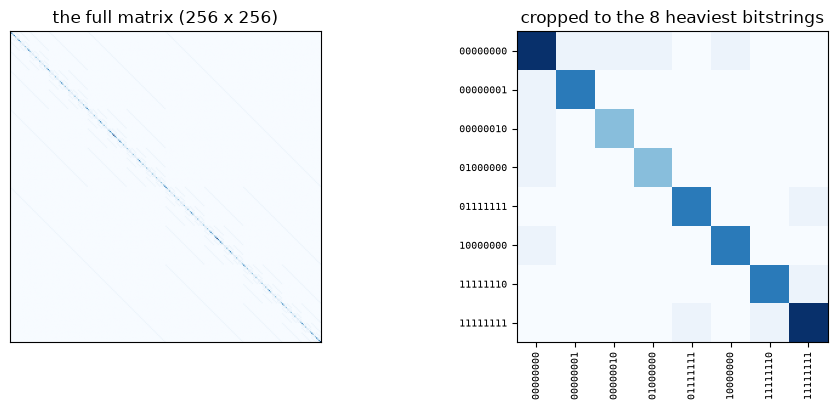

In [9]:
top_states = np.argsort(probs)[::-1][:8]  # the 8 heaviest bitstrings

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.2))
ax1.imshow(np.abs(H_mat), cmap="Blues")
ax1.set_title(f"the full matrix ({H_mat.shape[0]} x {H_mat.shape[0]})")
ax1.set_xticks([]), ax1.set_yticks([])

block = H_mat[np.ix_(sorted(top_states), sorted(top_states))]
im = ax2.imshow(np.abs(block), cmap="Blues")
labels = [f"{s:08b}" for s in sorted(top_states)]
ax2.set_xticks(range(8)), ax2.set_yticks(range(8))
ax2.set_xticklabels(labels, rotation=90, fontsize=7, family="monospace")
ax2.set_yticklabels(labels, fontsize=7, family="monospace")
ax2.set_title("cropped to the 8 heaviest bitstrings")
plt.tight_layout()
plt.show()

### ✍️ Your turn 1 · implement the crop

Complete `subspace_energy`. Given the full matrix and a collection of basis-state
indices, it should return the lowest eigenvalue of the cropped block.

Hints: `np.ix_(sel, sel)` selects rows *and* columns at once, and `np.linalg.eigvalsh`
returns eigenvalues of a symmetric matrix in ascending order. Write your two lines
between the `YOUR CODE HERE` markers, replacing the `raise` line; until you do, any
cell that calls the function stops with a friendly reminder rather than a cryptic error.

In [12]:
def subspace_energy(H_mat, states):
    """Lowest eigenvalue of H restricted to the given basis states."""
    sel = sorted(set(states))
    # ✏️ =============== YOUR CODE HERE ===============
    # TODO: build `block`: the rows AND columns of H_mat at `sel` (hint: np.ix_)
    # TODO: return the smallest eigenvalue of `block` (hint: np.linalg.eigvalsh)
    block = H_mat[np.ix_(sel, sel)]
    return np.linalg.eigvalsh(block)[0]
    # raise NotImplementedError("✏️ subspace_energy still needs your two lines of code!")
    # ✏️ ============== END OF YOUR CODE ==============

In [13]:
# self-check: does your function behave?
assert np.isclose(subspace_energy(H_mat, range(2**n)), E_exact), "the full list must give the exact energy"
assert np.isclose(subspace_energy(H_mat, [0]), H_mat[0, 0]), "one bitstring gives its diagonal entry"
assert subspace_energy(H_mat, top_states) >= E_exact - 1e-9, "a crop can never beat the true minimum"
print("✅ subspace_energy passes all checks")

✅ subspace_energy passes all checks


<details>
<summary>💡 <b>Solution: Your turn 1</b></summary>

```python
def subspace_energy(H_mat, states):
    sel = sorted(set(states))
    block = H_mat[np.ix_(sel, sel)]
    return np.linalg.eigvalsh(block)[0]
```

`np.ix_` builds the row/column index mesh, so `block[i, j]` is
$\langle b_i|H|b_j\rangle$ for your chosen bitstrings. The smallest eigenvalue of that
block is the best possible energy using only those bitstrings.

</details>

## 4 · Where does the list of bitstrings come from? Sampling

Here is the key observation. Suppose someone hands you a copy of the ground state.
You measure it. What do you get? A bitstring $b$, with probability $|c_b|^2$.

**Measurement is a machine that hands you important bitstrings.** The heavier a
bitstring's weight, the sooner it shows up in your samples. Rare, irrelevant
bitstrings almost never show up, and that's fine, because we didn't want them anyway.

Let's test that idea with a controlled experiment. We'll pretend we own a perfect
quantum computer by drawing one stream of 800 outcomes with the exact probabilities
$|c_b|^2$. For each smaller budget we use a **prefix of that same stream**. A prefix is
simply the first $N$ outcomes. It is not a different sampling rule; it lets us
demonstrate convergence by adding shots without discarding any earlier result:

1. Keep the first 10 shots, then the first 25, then the first 50, and so on.
2. **Dedupe:** keep one copy of each distinct bitstring in each prefix.
3. **Crop and diagonalize** with your `subspace_energy`.

Because every longer prefix contains every earlier shot, these sampled subspaces are
nested. The variational guarantee therefore applies directly: the sampled energy can
only improve or stay fixed as the budget grows.

"Sampled" and "random" mean different distributions here. Sampled outcomes follow
$|c_b|^2$, so high-weight bitstrings are more likely. For the control, we generate many
uniformly random orderings of all 256 basis states, so every bitstring is equally likely
to occupy each position, and take prefixes with the same lengths as the sampled lists.
The line shows the median random error; the shaded band shows the middle half of random
trials. That makes the control far less dependent on one lucky or unlucky random list.


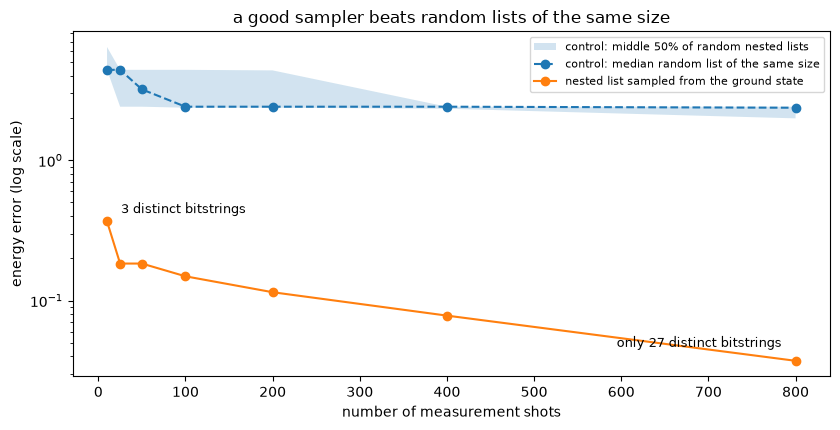

distinct bitstrings at each shot count: {np.int64(10): 3, np.int64(25): 7, np.int64(50): 10, np.int64(100): 13, np.int64(200): 14, np.int64(400): 20, np.int64(800): 27}


In [14]:
def sample_stream(probs, shots, seed=2026):
    """Pretend-measure `shots` times and preserve the order of the outcomes."""
    local_rng = np.random.default_rng(seed)
    return local_rng.choice(len(probs), size=shots, p=probs)


shot_counts = np.array([10, 25, 50, 100, 200, 400, 800])
stream = sample_stream(probs, int(shot_counts[-1]))

errors_sampled, n_distinct = [], []
for shots in shot_counts:
    seen = np.unique(stream[:shots])
    n_distinct.append(len(seen))
    errors_sampled.append(subspace_energy(H_mat, seen) - E_exact)

# Each control trial is one random ordering. Prefixes inside a trial are nested.
control_rng = np.random.default_rng(314159)
n_controls = 100
errors_random = np.empty((n_controls, len(shot_counts)))
for trial in range(n_controls):
    random_order = control_rng.permutation(2**n)
    for j, k in enumerate(n_distinct):
        errors_random[trial, j] = subspace_energy(H_mat, random_order[:k]) - E_exact

random_q25, random_median, random_q75 = np.quantile(
    errors_random, [0.25, 0.50, 0.75], axis=0
)
errors_sampled = np.asarray(errors_sampled)

# Nested variational subspaces should be non-increasing, up to roundoff.
assert np.all(np.diff(errors_sampled) <= 1e-10)

fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.fill_between(shot_counts, random_q25, random_q75, alpha=0.20,
                label="control: middle 50% of random nested lists")
ax.semilogy(shot_counts, random_median, "o--",
            label="control: median random list of the same size")
ax.semilogy(shot_counts, errors_sampled, "o-",
            label="nested list sampled from the ground state")
ax.annotate(f"{n_distinct[0]} distinct bitstrings",
            (shot_counts[0], errors_sampled[0]),
            textcoords="offset points", xytext=(10, 6), fontsize=9)
ax.annotate(f"only {n_distinct[-1]} distinct bitstrings",
            (shot_counts[-1], errors_sampled[-1]),
            textcoords="offset points", xytext=(-10, 10), ha="right", fontsize=9)
ax.set_xlabel("number of measurement shots")
ax.set_ylabel("energy error (log scale)")
ax.set_title("a good sampler beats random lists of the same size")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
print(f"distinct bitstrings at each shot count: {dict(zip(shot_counts, n_distinct))}")

**How to read this chart.** Both axes deserve a second look:

- **Across:** the measurement budget, from 10 to 800 shots. Every point uses a prefix
  of one cumulative stream, so the red subspaces are genuinely nested.
- **Up:** how far the cropped energy sits above the exact answer. The scale is
  logarithmic: dropping one gridline means a **10x** smaller error.

Now the curves:

- **Sampled:** more shots occasionally reveal a new useful bitstring. When that
  happens the energy steps down; when a prefix contains only repeats, it stays put.
  The curve cannot rise because no earlier basis state is ever removed.
- **Random control:** the dashed line is the median of 100 random nested lists with
  exactly the same number of basis states as the sampled list. The shaded band is the
  25th-to-75th percentile range. Even unusually favorable random lists usually lag the
  sampled support.

Same list sizes, sharply different quality. The lesson is unchanged: **what makes a
subspace good is *which* bitstrings it contains, not how many.** Measurement, by its
nature, favors the right ones.

> **Support now, frequencies later.** In this plain crop, a repeated bitstring does not
> add a new basis vector, so diagonalization only needs the set of distinct outcomes.
> In notebook 3, configuration recovery will also use *how often* each outcome appeared
> to estimate orbital occupancies. We will therefore preserve frequencies there.

**🧠 Checkpoint 4.** A bitstring that never appears in your samples has exactly zero
influence on the cropped answer. What does that imply if some *important* bitstring is
rare in your sampling distribution?

<details>
<summary>💡 <b>Check your answer</b></summary>

Your energy stays stuck above the truth by roughly that bitstring's contribution until
you either take enough shots to catch it, or improve the state you're sampling from.
**The quality of the sampler sets the quality of the answer.** That's exactly why a
quantum computer, which can prepare states that overlap well with hard ground states,
is the interesting sampler here, and why "more shots" is the knob you turn when close.

</details>

## 5 · The central result: a mediocre circuit is good enough

In real life nobody hands us the exact ground state. Can we still win with a **rough
approximation**? Let's build one, on purpose, without any optimization:

- `H` + a ladder of `CX`: a **GHZ state**, the $n$-qubit big brother of section 2's
  Bell state, $\left(|00\ldots0\rangle + |11\ldots1\rangle\right)/\sqrt{2}$: it visits
  *both* magnet wells at once,
- a small `RY` twist on every qubit, spreading some probability onto nearby bitstrings.

That's it. No training loop, no calibration. A first guess, drawn from intuition.
(And no compile step either: these gates are already native to our simulator, so the
sampler takes the circuit as-is. Fancier circuits and real hardware need their circuits
rewritten first; that step joins the workflow in notebook 3.)

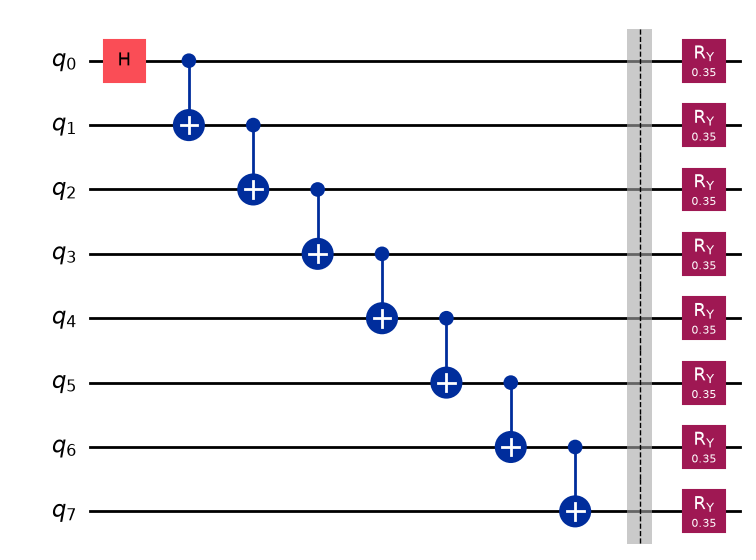

In [15]:
def guess_circuit(n, theta):
    qc = QuantumCircuit(n)
    qc.h(0)
    for i in range(n - 1):
        qc.cx(i, i + 1)          # GHZ ladder: both wells
    qc.barrier()
    for i in range(n):
        qc.ry(theta, i)          # a deliberate twist
    return qc


theta = 0.35
qc = guess_circuit(n, theta)
qc.draw("mpl", fold=-1)

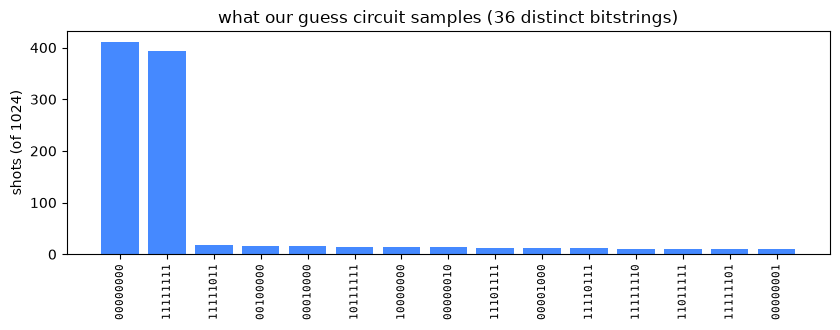

In [16]:
shots = 1024
qc_meas = qc.copy()
qc_meas.measure_all()
counts = StatevectorSampler(seed=7).run([qc_meas], shots=shots).result()[0].data.meas.get_counts()

top15 = dict(sorted(counts.items(), key=lambda kv: -kv[1])[:15])
fig, ax = plt.subplots(figsize=(8.5, 3.4))
ax.bar(range(len(top15)), list(top15.values()), color="#4589ff")
ax.set_xticks(range(len(top15)))
ax.set_xticklabels(top15.keys(), rotation=90, fontsize=8, family="monospace")
ax.set_ylabel(f"shots (of {shots})")
ax.set_title(f"what our guess circuit samples ({len(counts)} distinct bitstrings)")
plt.tight_layout()
plt.show()

Now the head-to-head. Two ways to turn this circuit into an energy:

1. **Trust the circuit's state:** compute its expectation value
   $\langle \psi | H | \psi \rangle$. Every imperfect amplitude in $\psi$ contributes
   to that average.
2. **Only trust its suggestions:** keep the distinct bitstrings it produced, crop, and
   diagonalize. The classical eigensolver finds the best possible amplitudes supported
   on that list.

<details>
<summary>🔎 <b>For context: how this differs from VQE</b></summary>

The first strategy is the objective used by the **variational quantum eigensolver
(VQE)**. Full VQE repeatedly estimates $\langle \psi(\theta)|H|\psi(\theta)\rangle$
and asks a classical optimizer to retune the circuit angles. For a Hamiltonian written
as a sum of Pauli terms, estimating that expectation value on hardware generally
requires circuits measured in several bases. It is not the same computational-basis
sampling used to collect SQD's candidate bitstrings.

SQD asks less of the circuit state. Its computational-basis shots identify useful
support, and the classical diagonalization replaces the sampled state's coefficients.
That is why the two methods respond differently to an imperfect ansatz.

</details>

exact ground energy:          -7.405591
circuit's own energy:         -6.176948   (error 1.23e+00)
diagonalize its samples:      -7.368448   (error 3.71e-02)


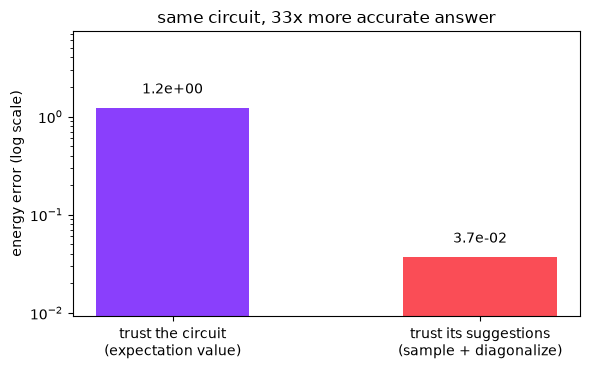

In [17]:
E_circuit = Statevector(qc).expectation_value(H).real
sampled = [int(b, 2) for b in counts]
E_sqd = subspace_energy(H_mat, sampled)

err_circuit = E_circuit - E_exact
err_sqd = E_sqd - E_exact
print(f"exact ground energy:          {E_exact:.6f}")
print(f"circuit's own energy:         {E_circuit:.6f}   (error {err_circuit:.2e})")
print(f"diagonalize its samples:      {E_sqd:.6f}   (error {err_sqd:.2e})")

fig, ax = plt.subplots(figsize=(6, 3.8))
bars = ax.bar(["trust the circuit\n(expectation value)", "trust its suggestions\n(sample + diagonalize)"],
              [err_circuit, err_sqd], color=["#8a3ffc", "#fa4d56"], width=0.5)
ax.set_yscale("log")
ax.set_ylim(err_sqd / 4, err_circuit * 6)  # headroom so the value labels clear the title
ax.set_ylabel("energy error (log scale)")
ax.set_title(f"same circuit, {err_circuit / err_sqd:,.0f}x more accurate answer")
for bar, v in zip(bars, [err_circuit, err_sqd]):
    ax.text(bar.get_x() + bar.get_width() / 2, v * 1.4, f"{v:.1e}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

**The same circuit, a far better answer.** The circuit state itself is over one model
energy unit wrong, yet its *samples* support an energy tens of times more accurate.
All we changed is what we asked of the circuit: not "be the ground state" but "tell me
where the ground state lives."

This is why SQD can tolerate imperfect circuits: diagonalization repairs coefficients
as long as the sampled support contains useful basis states.

**🧠 Checkpoint 5.** Why does "sample + diagonalize" beat the circuit's own energy so badly?

<details>
<summary>💡 <b>Check your answer</b></summary>

The circuit's own energy is charged for every wrong amplitude: too much weight here, a
wrong sign there, and the expectation value climbs. The cropped diagonalization discards
the circuit's amplitudes entirely and keeps only its **support** (which bitstrings
appeared). The classical eigensolver then reassigns all the amplitudes optimally. The
circuit only needs to visit the right neighborhoods, not to live there perfectly.

</details>

In [18]:
def evaluate_theta(theta, shots=1024, seed=7):
    """Compare state quality, sampled support, and projected energy at one twist."""
    trial_circuit = guess_circuit(n, theta)
    measured = trial_circuit.copy()
    measured.measure_all()
    trial_counts = (
        StatevectorSampler(seed=seed)
        .run([measured], shots=shots)
        .result()[0]
        .data.meas.get_counts()
    )
    circuit_energy = Statevector(trial_circuit).expectation_value(H).real
    support = [int(bitstring, 2) for bitstring in trial_counts]
    sqd_energy = subspace_energy(H_mat, support)
    return {
        "theta": theta,
        "counts": trial_counts,
        "n_distinct": len(trial_counts),
        "circuit_error": circuit_energy - E_exact,
        "sqd_error": sqd_energy - E_exact,
    }

### ✍️ Your turn 2 · map the sweet spot

A larger twist makes the circuit's own state worse, but it can initially make the
sampled support more diverse. Too much twist eventually scatters a fixed shot budget
so broadly that important states can be missed.

Before running the cell, sketch three predictions across the sweep:

- Does the circuit's own energy error rise or fall with `theta`?
- Does the number of distinct sampled bitstrings rise forever?
- Must the sample-and-diagonalize error track either one monotonically?

Then run the sweep and explain where the useful middle ground appears.

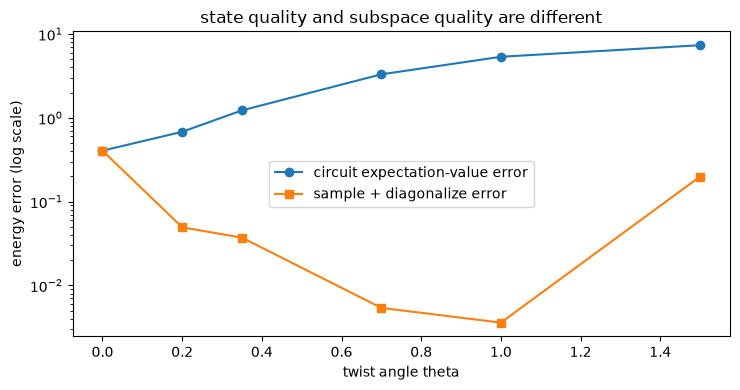

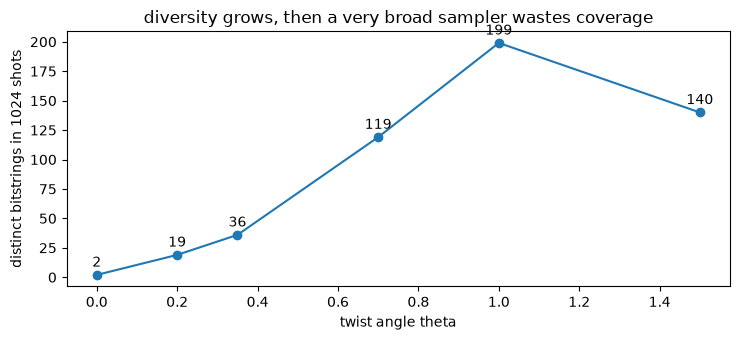

theta=0.00 | distinct=  2 | circuit error=4.056e-01 | SQD error=4.056e-01
theta=0.20 | distinct= 19 | circuit error=6.819e-01 | SQD error=4.940e-02
theta=0.35 | distinct= 36 | circuit error=1.229e+00 | SQD error=3.714e-02
theta=0.70 | distinct=119 | circuit error=3.311e+00 | SQD error=5.389e-03
theta=1.00 | distinct=199 | circuit error=5.362e+00 | SQD error=3.593e-03
theta=1.50 | distinct=140 | circuit error=7.371e+00 | SQD error=1.995e-01


In [19]:
theta_values = [0.0, 0.2, 0.35, 0.7, 1.0, 1.5]
theta_results = [evaluate_theta(theta) for theta in theta_values]

circuit_errors = [item["circuit_error"] for item in theta_results]
sqd_errors = [item["sqd_error"] for item in theta_results]
distinct_counts = [item["n_distinct"] for item in theta_results]

fig, ax = plt.subplots(figsize=(7.5, 4.0))
ax.semilogy(theta_values, circuit_errors, "o-", label="circuit expectation-value error")
ax.semilogy(theta_values, sqd_errors, "s-", label="sample + diagonalize error")
ax.set_xlabel("twist angle theta")
ax.set_ylabel("energy error (log scale)")
ax.set_title("state quality and subspace quality are different")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7.5, 3.5))
ax.plot(theta_values, distinct_counts, "o-")
for theta_value, count in zip(theta_values, distinct_counts):
    ax.annotate(str(count), (theta_value, count), textcoords="offset points", xytext=(0, 6), ha="center")
ax.set_xlabel("twist angle theta")
ax.set_ylabel(f"distinct bitstrings in {shots} shots")
ax.set_title("diversity grows, then a very broad sampler wastes coverage")
plt.tight_layout()
plt.show()

for item in theta_results:
    print(f"theta={item['theta']:>4.2f} | distinct={item['n_distinct']:>3} | "
          f"circuit error={item['circuit_error']:.3e} | SQD error={item['sqd_error']:.3e}")

<details>
<summary>💡 <b>Interpretation: Your turn 2</b></summary>

The circuit's own energy degrades as the twist grows. The SQD answer can improve at
first because a moderately broader sampler visits more useful basis states. It does
not improve forever: near `theta = 1.5`, the fixed shot budget is spread across a less
focused distribution and the projected answer can worsen again.

The lesson is not "make the circuit as random as possible." It is **cover the right
support with enough diversity**. Circuit fidelity, number of distinct outcomes, and
subspace quality are related, but none is a substitute for the other.

</details>

## 🔁 Recap: the SQD recipe, version 0.1

1. **Prepare** any state that overlaps well with the ground state (perfection not required).
2. **Measure** it many times and collect bitstrings.
3. For a plain projected solve, **keep the distinct bitstrings**: they define a small subspace.
4. **Crop** the Hamiltonian to that subspace and **diagonalize classically**.
5. The lowest eigenvalue is your energy: an upper bound that improves whenever a nested list grows.

Three intuitions to carry forward:

| Intuition | One-liner |
|---|---|
| Concentration | Physical ground states often live on a few bitstrings |
| Variational safety | A cropped answer approaches the truth from above, never below |
| Division of labor | The quantum computer proposes, the classical computer disposes |

One distinction will matter later: plain diagonalization uses **support**, while
configuration recovery also uses **sample frequencies** to infer which seats are
usually occupied.

**Next up (notebook 2):** the bitstrings become *electron configurations*, the Hamiltonian
becomes a *molecule*, and the crop-and-diagonalize step becomes one function call:
`solve_fermion`.